In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

Primeiras linhas do conjunto de dados:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

Precisão do modelo: 98.00%


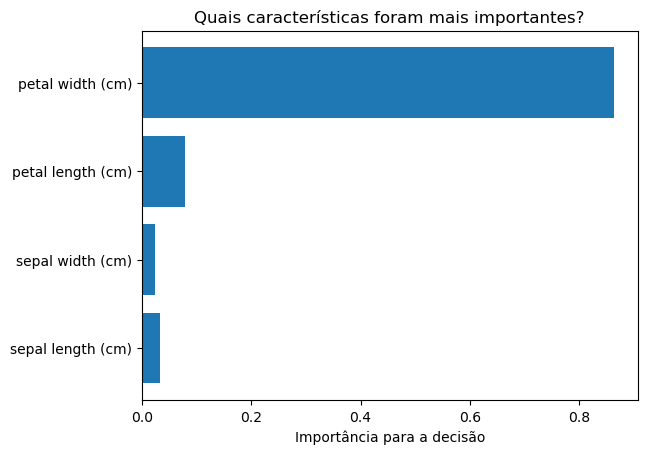

In [2]:
# 1. Carregar os dados corrigidos do Iris do sklearn
# https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['target'] = iris.target

print("Primeiras linhas do conjunto de dados:")
print(df.head())

# 2. Separar dados de treino e teste
# 'target' é a coluna que queremos prever, então a removemos de X para usarmos como y
X = df.drop('target', axis=1) # Características (medidas)
y = df['target']              # Alvo (espécie da flor)

# Dividir os dados em 2/3 para treino e 1/3 para teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=1/3, random_state=42)
# 3. Escolher e treinar o modelo (Árvore de Decisão)
modelo = DecisionTreeClassifier()
modelo.fit(X_train, y_train)

# 4. Fazer previsões e avaliar
previsoes = modelo.predict(X_test)
precisao = accuracy_score(y_test, previsoes)

print(f"\nPrecisão do modelo: {precisao * 100:.2f}%")

# 5. Visualizar a importância de cada característica
plt.barh(iris.feature_names, modelo.feature_importances_)
plt.xlabel("Importância para a decisão")
plt.title("Quais características foram mais importantes?")
plt.show()

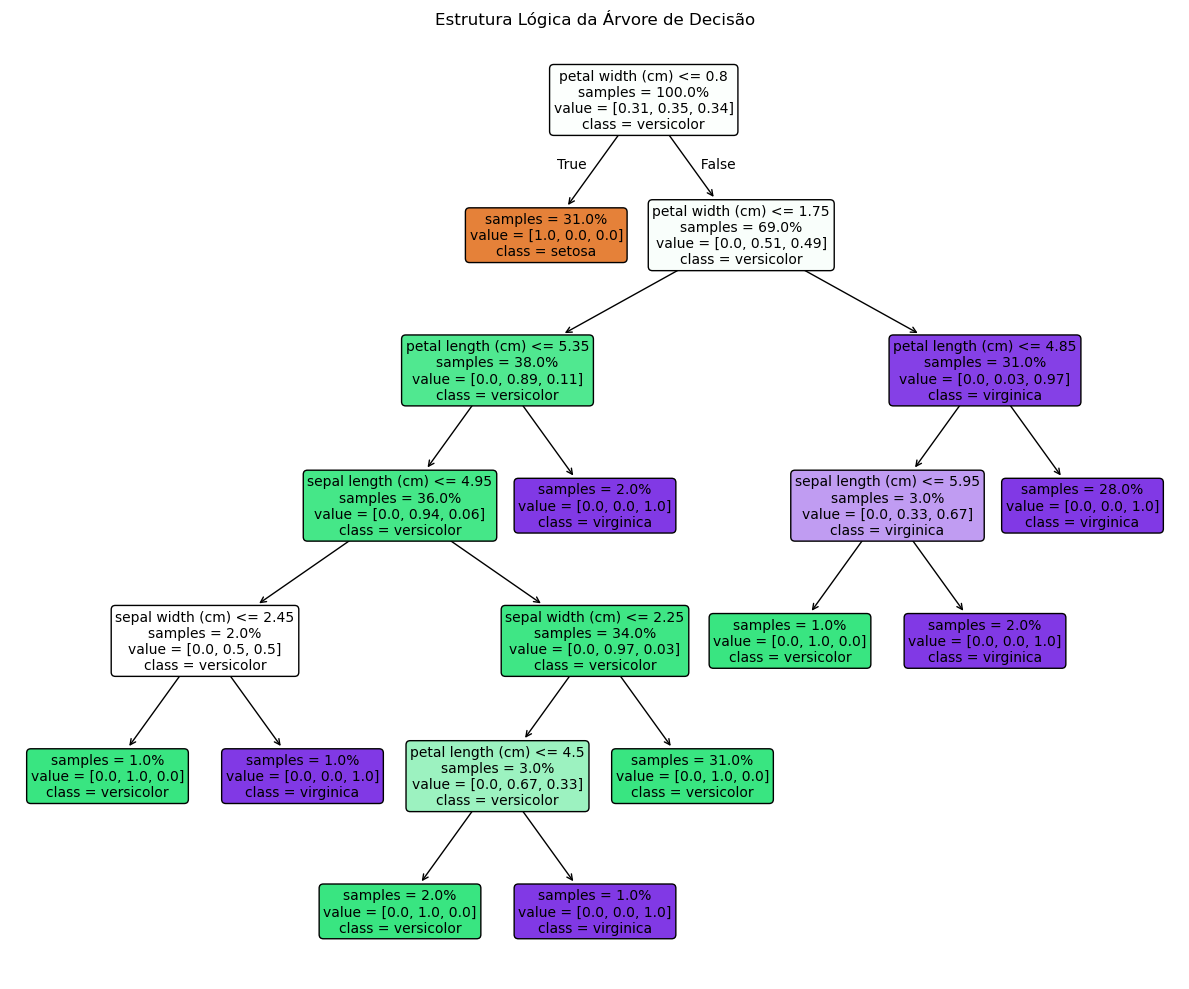

In [3]:
from sklearn.tree import plot_tree

# Ajustar o tamanho da figura para melhor visualização
plt.figure(figsize=(12, 10), dpi=100)

# Desenhar a árvore
plot_tree(modelo, 
            feature_names=iris.feature_names,  # Nome das colunas
            class_names=iris.target_names,     # Nome das espécies
            filled=True,                       # Colorir os nós
            rounded=True,                      # Deixar as caixas arredondadas
            proportion=True,
            impurity=False,
            precision=2,
            fontsize=10
        )

plt.title("Estrutura Lógica da Árvore de Decisão")
plt.tight_layout()
plt.savefig("arvore_decisao.png", dpi=300, bbox_inches='tight')
plt.show()

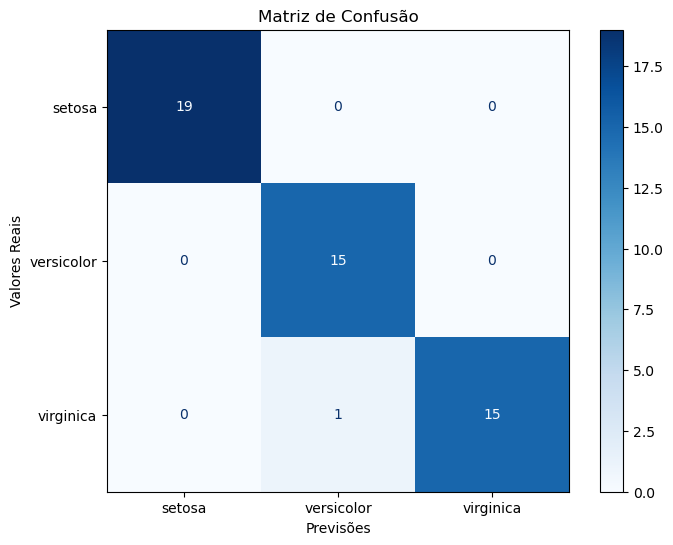

In [4]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Criar a matriz de confusão
cm = confusion_matrix(y_test, previsoes)

# 2. Configurar a visualização
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=iris.target_names)

# 3. Desenhar o gráfico
disp.plot(cmap='Blues', ax=ax)
ax.grid(False)
plt.title("Matriz de Confusão")
plt.xlabel("Previsões")
plt.ylabel("Valores Reais")
plt.show()